# Comparing dataset with CosmoPower

In [30]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cosmopower

In [31]:
MAX_SAMPLES = 100
NUM_ELL = 2999

train_cosmologies = np.loadtxt("../data/train/cosmologies.txt")
data = np.zeros((MAX_SAMPLES, 3, NUM_ELL))
for i in range(1, MAX_SAMPLES+1):
    cl_tt, cl_te, cl_ee = np.loadtxt(f"../data/train/cl_{i}.txt", unpack=True)
    data[i-1, 0] = cl_tt
    data[i-1, 1] = cl_te
    data[i-1, 2] = cl_ee

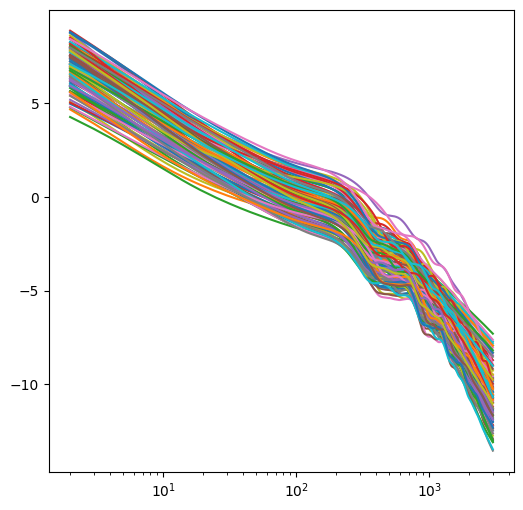

In [32]:
fig = plt.figure(figsize=(6, 6))

ell = np.arange(2, 3001)
factor = ell*(ell+1)/(2*np.pi)
for i in range(MAX_SAMPLES):
    cl_tt, cl_te, cl_ee = data[i]
    plt.semilogx(ell, np.log(cl_tt/factor))
    # axs[1].semilogx(ell, cl_te)
    # axs[2].semilogx(ell, cl_ee)

In [33]:
# load pre-trained NN model: maps cosmological parameters to CMB TT log-C_ell
ipynb_path = os.path.dirname(os.path.realpath("__file__"))
cp_nn_tt = cosmopower.cosmopower_NN(restore=True,
                                    restore_filename="/Users/joao/cosmo/cosmopower/cosmopower/trained_models/CP_paper/CMB/cmb_TT_NN")

Text(0, 0.5, '$[C_\\mathrm{CosmoPower}^{TT}(\\ell) - C_\\mathrm{CAMB}^{TT}(\\ell)] / C_\\mathrm{CAMB}^{TT}(\\ell)$')

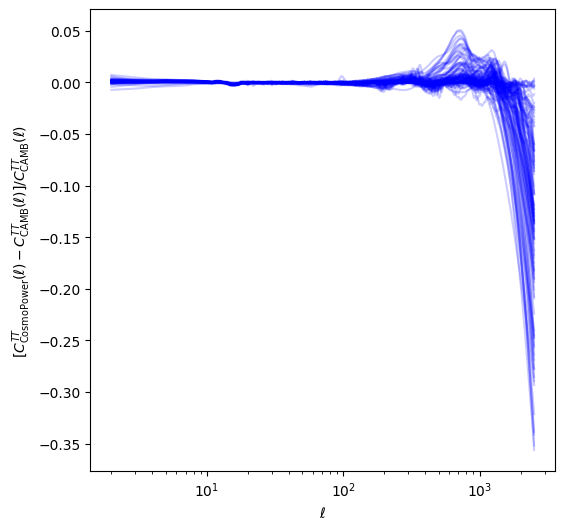

In [34]:
fig = plt.figure(figsize=(6, 6))

ell = np.arange(2, 3001)
for i in range(MAX_SAMPLES):
    h, omch2, ombh2, ln1010As, ns, tau = train_cosmologies[i]
    params = {"h": [h], "omega_cdm": [omch2], "omega_b": [ombh2], "ln10^{10}A_s": [ln1010As], "n_s": [ns], "tau_reio": [tau], }

    cl_tt_cosmopower = cp_nn_tt.ten_to_predictions_np(params)[0]
    ell_cosmopower = ell[:len(cl_tt_cosmopower)]
    cl_tt_cosmopower *= ell_cosmopower*(ell_cosmopower+1)/(2*np.pi)
    cl_tt, cl_te, cl_ee = data[i]
    cl_tt = cl_tt[:len(cl_tt_cosmopower)]/units_factor
    units_factor = (2.7255*1e6)**2
    plt.semilogx(ell_cosmopower, (cl_tt_cosmopower - cl_tt)/cl_tt, color="blue", alpha=0.2)
plt.xlabel("$\\ell$")
plt.ylabel("$[C_\\mathrm{CosmoPower}^{TT}(\\ell) - C_\\mathrm{CAMB}^{TT}(\\ell)] / C_\\mathrm{CAMB}^{TT}(\\ell)$")

In [35]:
from time import perf_counter
start = perf_counter()
cl_tt_cosmopower = cp_nn_tt.ten_to_predictions_np(params)[0]
end = perf_counter()
print(f"Took {end - start:.3f} seconds")

Took 0.004 seconds
